# Hierarchical modelling from scratch: the alien coins

**Day 3 — companion notebook.** Brandon Turner, Alexander Fengler.

A Python version of `binomial_Bayes_hier.R`. We write the sampler by hand
first — it is about thirty lines of numpy — and only then call PyMC, so the
library is doing something you have already seen.

The example is the one from the slides: **alien coins**, each with some
magnetic property that pushes $P(\text{heads})$ away from $0.5$ by a different
amount. Flip each one a fixed number of times, estimate each one's bias.

The same question, asked three ways:

| | what you assume | what you get |
|---|---|---|
| **no pooling** | every coin is unrelated | each coin's own flips, and nothing else |
| **fixed population** | coins share a population you *already know* | shrinkage toward a known centre |
| **hierarchical** | coins share a population you must **also estimate** | shrinkage, plus the population itself |

The third is the one worth the trouble. What it buys and what it costs is the
whole content of this notebook.

<details class="sbi-note">
<summary>▶️ <b>Running this on Google Colab</b></summary>

The cell below is a no-op on your own machine. On Colab it installs the stack
and downloads the shared helper module, which lives one directory up in the
repository and is therefore not importable there.

Expect the install to take a few minutes. If Colab asks you to restart the
runtime, do it and then run the cell again — the second run is a no-op.

</details>

In [1]:
# --- Google Colab bootstrap; does nothing anywhere else ---------------------
import importlib.util, subprocess, sys, urllib.error, urllib.request

IN_COLAB = importlib.util.find_spec("google.colab") is not None

_REFS = ("main", "af-reductions-toy-models")
_RAW = "https://raw.githubusercontent.com/stefanradev93/sbi4cogsci/{ref}/tutorials/"


def _fetch(module):
    for ref in _REFS:
        try:
            urllib.request.urlretrieve(_RAW.format(ref=ref) + module, module)
            return ref
        except urllib.error.HTTPError:
            continue
    raise RuntimeError(f"could not fetch {module} from any of {_REFS}")


if IN_COLAB:
    # numba>=0.61 is REQUIRED, not cosmetic. pytensor resolves linker="auto" to
    # its numba backend, and numba renamed FunctionModel's first field
    # addr -> c_addr in 0.61. Colab preinstalls an older numba, and pytensor
    # declares numba only as an optional extra, so pip leaves it in place.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "numba>=0.61", "pymc>=6.2", "arviz>=1.2"], check=True)
    for _mod in ["sbi4cogsci_style.py"]:
        print(f"  fetched {_mod} from {_fetch(_mod)}")
    print("Colab setup done.")

In [2]:
import sys, pathlib, warnings

sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pymc as pm
import arviz as az
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

RANDOM_SEED = sum(map(ord, "sbi4cogsci-alien-coins"))
rng = np.random.default_rng(RANDOM_SEED)

print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 6.2.0 | arviz 1.2.0


## 1. The coins, and where they come from

The generative story, exactly as the slides draw it:

$$
\alpha,\ \beta \quad\longrightarrow\quad
p_i \sim \text{Beta}(\alpha, \beta) \quad\longrightarrow\quad
D_i \sim \text{Bernoulli}(p_i)\ \ (n \text{ flips}).
$$

Downward it is a recipe for making data. Upward it is the inference problem:
from $D$, recover every $p_i$ *and* the $\alpha, \beta$ behind them.

We simulate, so everything later is checkable against a known truth.

In [3]:
N_FLIPS = 100          # flips per coin
S_COINS = 24           # number of coins
TRUE_ALPHA, TRUE_BETA = 10.0, 15.0

true_p = rng.beta(TRUE_ALPHA, TRUE_BETA, size=S_COINS)
data = rng.binomial(1, true_p[:, None], size=(S_COINS, N_FLIPS))   # 0/1 flips
x = data.sum(axis=1)                                               # heads per coin

pop_mean = TRUE_ALPHA / (TRUE_ALPHA + TRUE_BETA)
print(f"population mean = alpha/(alpha+beta) = {pop_mean:.3f}")
print(f"true p ranges {true_p.min():.3f} to {true_p.max():.3f}")
print(f"heads out of {N_FLIPS}: {x}")

population mean = alpha/(alpha+beta) = 0.400
true p ranges 0.199 to 0.587
heads out of 100: [31 34 33 32 61 31 40 31 19 30 34 56 42 46 31 35 54 27 44 42 40 32 43 37]


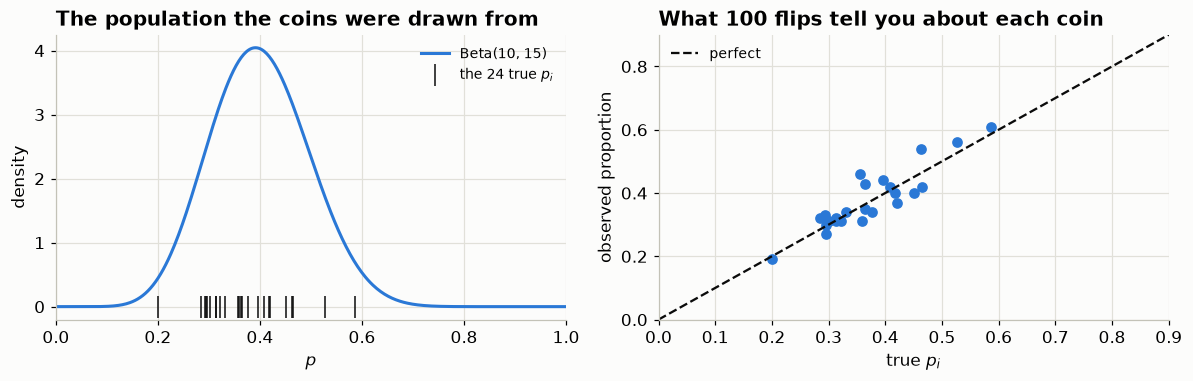

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

grid = np.linspace(0, 1, 400)
ax1.plot(grid, stats.beta.pdf(grid, TRUE_ALPHA, TRUE_BETA), color=S.PRIMARY,
         lw=2, label=rf"Beta({TRUE_ALPHA:.0f}, {TRUE_BETA:.0f})")
ax1.plot(true_p, np.zeros_like(true_p), "|", color=S.TRUTH, ms=14,
         label="the 24 true $p_i$")
ax1.set(title="The population the coins were drawn from", xlabel="$p$",
        ylabel="density", xlim=(0, 1))
ax1.legend(fontsize=9)

ax2.plot(true_p, x / N_FLIPS, "o", color=S.PRIMARY, ms=6, ls="none")
lims = (0, 0.9)
ax2.plot(lims, lims, "--", color=S.TRUTH, lw=1.5, label="perfect")
ax2.set(title="What 100 flips tell you about each coin", xlabel="true $p_i$",
        ylabel="observed proportion", xlim=lims, ylim=lims)
ax2.legend(fontsize=9)
fig.tight_layout()

The right panel is the **no-pooling** estimate — each coin's own proportion of
heads and nothing else. It scatters around the truth with no systematic bias.

Keep that in mind, because next we make it biased on purpose and end up closer
to the truth.

## 2. One coin, by hand

One coin, and the three pieces the R script writes: a likelihood, a prior,
their product. In logs — a product of 100 probabilities underflows fast.

In [5]:
def log_lik(p, flips):
    """log P(flips | p) for one coin. Bernoulli, summed over flips."""
    if not (0.0 < p < 1.0):
        return -np.inf
    return float(np.sum(stats.bernoulli.logpmf(flips, p)))


def log_prior(p, alpha, beta):
    """log Beta(p | alpha, beta) — the population, seen from one coin."""
    return float(stats.beta.logpdf(p, alpha, beta))


def log_post(p, flips, alpha, beta):
    """Unnormalised log posterior. -inf outside the support, as in the R."""
    out = log_lik(p, flips) + log_prior(p, alpha, beta)
    return -np.inf if np.isnan(out) else out


coin = 0
print(f"coin {coin}: {x[coin]} heads out of {N_FLIPS}   (true p = {true_p[coin]:.3f})")
print(f"  log-likelihood at p = 0.4 : {log_lik(0.4, data[coin]):.3f}")
print(f"  log-prior      at p = 0.4 : {log_prior(0.4, TRUE_ALPHA, TRUE_BETA):.3f}")
print(f"  log-posterior  at p = 0.4 : {log_post(0.4, data[coin], TRUE_ALPHA, TRUE_BETA):.3f}")

coin 0: 31 heads out of 100   (true p = 0.302)
  log-likelihood at p = 0.4 : -63.652
  log-prior      at p = 0.4 : 1.394
  log-posterior  at p = 0.4 : -62.258


One parameter, so we can just look at the posterior on a grid. Worth doing
once: this is the thing MCMC approximates once a grid stops being an option.

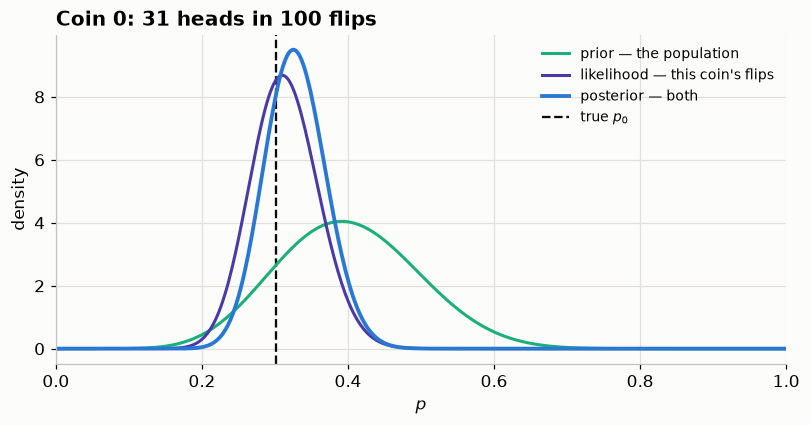

In [6]:
ps = np.linspace(0.001, 0.999, 400)
lp_like = np.array([log_lik(p, data[coin]) for p in ps])
lp_prior = np.array([log_prior(p, TRUE_ALPHA, TRUE_BETA) for p in ps])
lp_post = lp_like + lp_prior


def to_density(logs):
    """Exponentiate a log-density safely and normalise it for plotting."""
    d = np.exp(logs - logs.max())
    return d / np.trapezoid(d, ps)


fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(ps, to_density(lp_prior), color=S.ALT, lw=2, label="prior — the population")
ax.plot(ps, to_density(lp_like), color=S.NAIVE, lw=2, label="likelihood — this coin's flips")
ax.plot(ps, to_density(lp_post), color=S.PRIMARY, lw=2.5, label="posterior — both")
S.truth_line(ax, true_p[coin], axis="x", label=f"true $p_{{{coin}}}$")
ax.set(title=f"Coin {coin}: {x[coin]} heads in {N_FLIPS} flips", xlabel="$p$",
       ylabel="density", xlim=(0, 1))
ax.legend(fontsize=9)
fig.tight_layout()

The posterior sits between the likelihood and the prior, nearer whichever is
sharper. That is pooling, already visible before any hierarchy exists: the
population pulls the estimate toward it, by an amount that depends on how much
this coin's own data has to say.

## 3. Method 1 — sample every coin, with the population *known*

Now all 24 coins at once, with a Metropolis sampler written out. This is a
direct translation of the first sampler in the R script: a symmetric normal
proposal, an accept/reject on the log-posterior ratio, and one chain per coin
advancing in lockstep.

Note that it **assumes $\alpha$ and $\beta$ are known** and plugs in the true
values. That is cheating; section 5 removes it. One idea at a time, which is
why the R script goes in this order.

In [7]:
def metropolis_known_pop(alpha, beta, n_iter=2000, tune=0.05, seed=RANDOM_SEED):
    """One Metropolis chain per coin. alpha/beta fixed and given."""
    rng_m = np.random.default_rng(seed)
    p_chain = np.empty((n_iter, S_COINS))
    lp = np.empty(S_COINS)

    p_chain[0] = rng_m.beta(1.0, 1.0, S_COINS)      # "your guess is as good as mine"
    for j in range(S_COINS):
        lp[j] = log_post(p_chain[0, j], data[j], alpha, beta)

    n_acc = np.zeros(S_COINS)
    for t in range(1, n_iter):
        prop = rng_m.normal(p_chain[t - 1], tune)    # symmetric -> ratio is the whole rule
        for j in range(S_COINS):
            lp_prop = log_post(prop[j], data[j], alpha, beta)
            if np.log(rng_m.uniform()) < lp_prop - lp[j]:
                p_chain[t, j], lp[j], n_acc[j] = prop[j], lp_prop, n_acc[j] + 1
            else:
                p_chain[t, j] = p_chain[t - 1, j]
    return p_chain, n_acc / (n_iter - 1)


chain_known, acc_known = metropolis_known_pop(TRUE_ALPHA, TRUE_BETA)
print(f"acceptance rate: mean {acc_known.mean():.2f}, "
      f"range {acc_known.min():.2f}-{acc_known.max():.2f}")

acceptance rate: mean 0.66, range 0.64-0.69


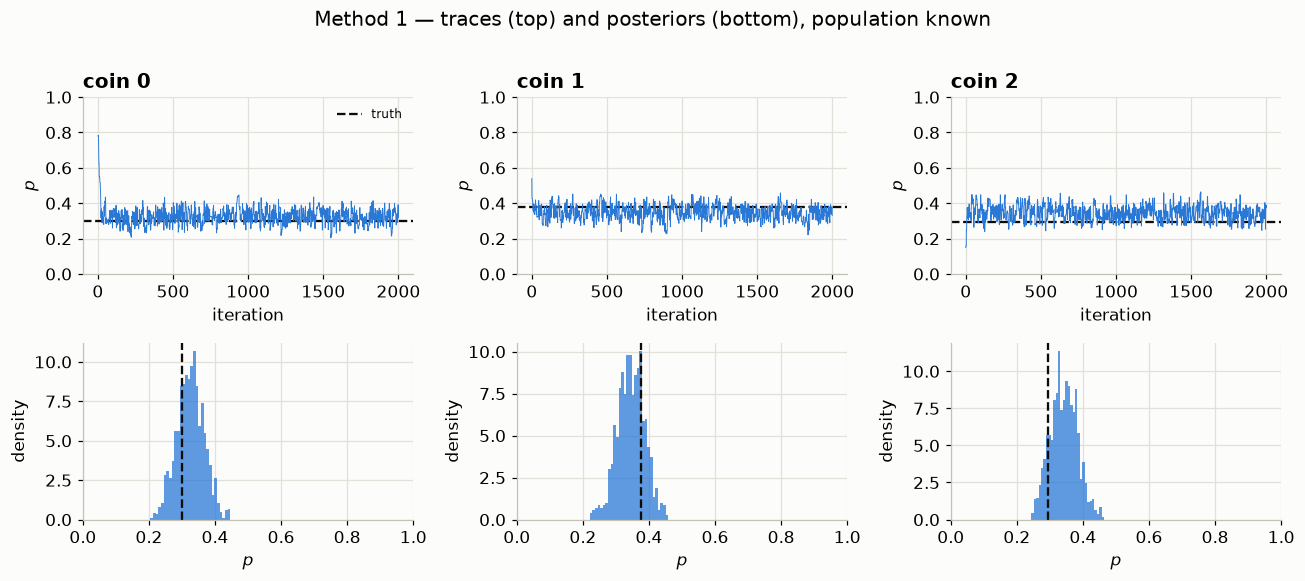

In [8]:
WARMUP = 500
post_known = chain_known[WARMUP:]

fig, axes = plt.subplots(2, 3, figsize=(12, 5.2))
for k, j in enumerate([0, 1, 2]):
    ax = axes[0, k]
    ax.plot(chain_known[:, j], lw=0.6, color=S.PRIMARY)
    S.truth_line(ax, true_p[j], label="truth")
    ax.set(title=f"coin {j}", xlabel="iteration", ylabel="$p$", ylim=(0, 1))
    if k == 0:
        ax.legend(fontsize=8)

    ax = axes[1, k]
    ax.hist(post_known[:, j], bins=30, density=True, color=S.PRIMARY, alpha=0.75)
    S.truth_line(ax, true_p[j], axis="x")
    ax.set(xlabel="$p$", ylabel="density", xlim=(0, 1))
fig.suptitle("Method 1 — traces (top) and posteriors (bottom), population known",
             y=1.01)
fig.tight_layout()

The chains leave their random starting points, settle, and wander around the
truth. The R script draws this for all 24 coins in a loop; three is enough.

The summary that matters is every coin at once, estimate against truth.

RMSE, no pooling      : 0.0407
RMSE, population known: 0.0381   (7% better)


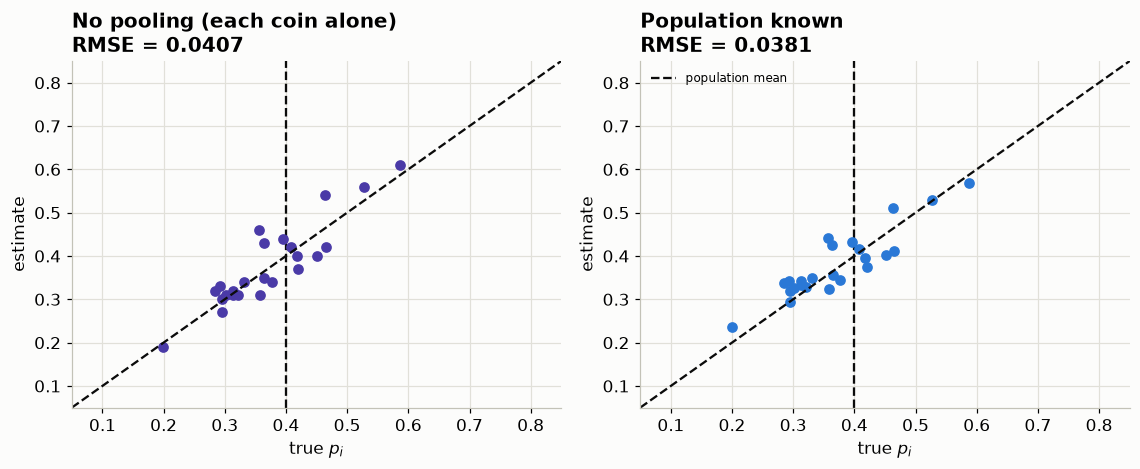

In [9]:
est_known = post_known.mean(axis=0)
naive = x / N_FLIPS


def recovery_panel(ax, est, title, colour):
    ax.plot(true_p, est, "o", color=colour, ms=6, ls="none")
    lims = (0.05, 0.85)
    ax.plot(lims, lims, "--", color=S.TRUTH, lw=1.5)
    S.truth_line(ax, pop_mean, axis="x", label="population mean")
    rmse = np.sqrt(np.mean((est - true_p) ** 2))
    ax.set(title=f"{title}\nRMSE = {rmse:.4f}", xlabel="true $p_i$",
           ylabel="estimate", xlim=lims, ylim=lims)
    return rmse


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.4))
rmse_naive = recovery_panel(ax1, naive, "No pooling (each coin alone)", S.NAIVE)
rmse_known = recovery_panel(ax2, est_known, "Population known", S.PRIMARY)
ax2.legend(fontsize=8, loc="upper left")
fig.tight_layout()

print(f"RMSE, no pooling      : {rmse_naive:.4f}")
print(f"RMSE, population known: {rmse_known:.4f}"
      f"   ({100 * (1 - rmse_known / rmse_naive):.0f}% better)")

<details class="sbi-key" open>
<summary>🔑 <b>The estimates got <i>biased</i>, and that is why they got better</b></summary>

Look at the right panel against the dashed identity line. The points are
pulled **toward the population mean** — coins above it are estimated a little
low, coins below it a little high. Each individual estimate is now biased.

And yet the RMSE is lower. That is the bias–variance trade in its cleanest
form: 100 flips leave real uncertainty about each coin, and borrowing the
population's opinion removes more variance than the bias it adds.

The trade is not free. If a coin genuinely sat far outside the population,
this would drag it wrongly, and no amount of pooling would tell you that had
happened. **Shrinkage is an assumption about how the world is organised**, not
a free improvement — and it is worth being explicit that you have made it.

</details>

## 4. But we cheated

Method 1 used `TRUE_ALPHA` and `TRUE_BETA` — the values that generated the
data. In any real study nobody hands you those. So what happens if you guess
the population wrong?

  true                     Beta(10, 15)  RMSE 0.0379


  too tight, wrong centre  Beta(40, 10)  RMSE 0.1526


  nearly flat              Beta(1.2, 1.2)  RMSE 0.0408


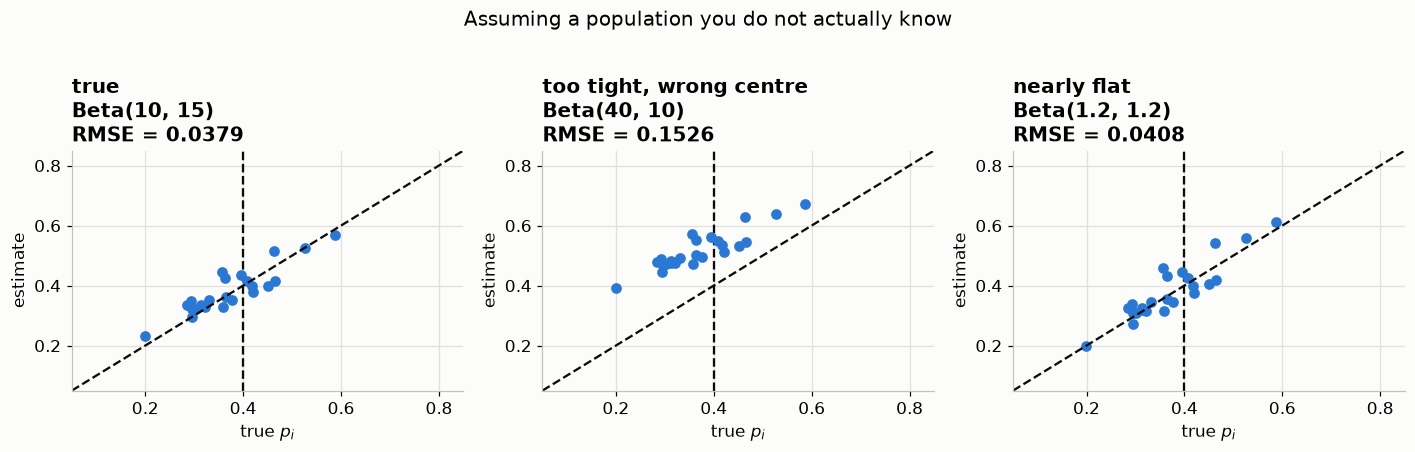

In [10]:
guesses = [("true", TRUE_ALPHA, TRUE_BETA),
           ("too tight, wrong centre", 40.0, 10.0),
           ("nearly flat", 1.2, 1.2)]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.0))
for ax, (label, a, b) in zip(axes, guesses):
    ch, _ = metropolis_known_pop(a, b, seed=RANDOM_SEED + 1)
    est = ch[WARMUP:].mean(axis=0)
    r = recovery_panel(ax, est, f"{label}\nBeta({a:g}, {b:g})", S.PRIMARY)
    print(f"  {label:24s} Beta({a:g}, {b:g})  RMSE {r:.4f}")
fig.suptitle("Assuming a population you do not actually know", y=1.02)
fig.tight_layout()

A confidently wrong population is worse than no pooling: it drags every coin
toward the wrong place. A nearly flat one is harmless and pointless — it just
reproduces the no-pooling answer, since a prior that says nothing lends
nothing.

So: **we want the pooling, but we do not know where to pool toward.** Estimate
that too.

## 5. Method 2 — the hierarchy: estimate $\alpha$ and $\beta$ as well

This is the graphical model from the slides. The double-circled nodes are
constants we choose; everything else is inferred:

$$
\alpha \sim \text{Gamma}(20, 1), \qquad
\beta \sim \text{Gamma}(20, 1),
$$
$$
p_i \mid \alpha, \beta \sim \text{Beta}(\alpha, \beta), \qquad
D_i \mid p_i \sim \text{Bernoulli}(p_i).
$$

The sampler alternates two moves: update every $p_i$ given the current
$\alpha, \beta$, then update $\alpha, \beta$ given the current $p_i$. That is
**Metropolis-within-Gibbs**, and it is the whole algorithm.

In [11]:
PRIOR_ALPHA = (20.0, 1.0)      # (shape, rate) for alpha
PRIOR_BETA = (20.0, 1.0)       # (shape, rate) for beta


def log_hyper(alpha, beta, ps):
    """log p(alpha, beta | ps): the Beta density of every coin, times the priors."""
    if alpha <= 0 or beta <= 0:
        return -np.inf
    lp = (stats.gamma.logpdf(alpha, PRIOR_ALPHA[0], scale=1 / PRIOR_ALPHA[1])
          + stats.gamma.logpdf(beta, PRIOR_BETA[0], scale=1 / PRIOR_BETA[1]))
    out = float(np.sum(stats.beta.logpdf(ps, alpha, beta)) + lp)
    return -np.inf if np.isnan(out) else out


def metropolis_hierarchical(n_iter=10_000, tune=0.05, tune_hyper=1.0,
                            seed=RANDOM_SEED):
    """Metropolis-within-Gibbs: the p's, then the hyperparameters, alternating."""
    rng_m = np.random.default_rng(seed)
    p_chain = np.empty((n_iter, S_COINS))
    phi = np.empty((n_iter, 2))                      # columns: alpha, beta

    p_chain[0] = rng_m.beta(1.0, 1.0, S_COINS)
    phi[0] = (5.0, 5.0)
    # Initialise the stored log-density with the SAME target the loop compares
    # against — the R script seeds it with the likelihood alone, which makes the
    # very first accept/reject inconsistent. It self-corrects, but there is no
    # reason to reproduce it.
    lp = np.array([log_post(p_chain[0, j], data[j], *phi[0]) for j in range(S_COINS)])

    n_acc_p, n_acc_h = np.zeros(S_COINS), 0
    for t in range(1, n_iter):
        a_prev, b_prev = phi[t - 1]

        # --- move 1: every coin's p, given the current population -----------
        prop = rng_m.normal(p_chain[t - 1], tune)
        for j in range(S_COINS):
            lp_prop = log_post(prop[j], data[j], a_prev, b_prev)
            if np.log(rng_m.uniform()) < lp_prop - lp[j]:
                p_chain[t, j], lp[j], n_acc_p[j] = prop[j], lp_prop, n_acc_p[j] + 1
            else:
                p_chain[t, j] = p_chain[t - 1, j]

        # --- move 2: the population, given the coins we just updated --------
        a_star, b_star = rng_m.normal(phi[t - 1], tune_hyper)
        num = log_hyper(a_star, b_star, p_chain[t])
        den = log_hyper(a_prev, b_prev, p_chain[t])
        if np.log(rng_m.uniform()) < num - den:
            phi[t], n_acc_h = (a_star, b_star), n_acc_h + 1
        else:
            phi[t] = phi[t - 1]

        # the p-densities were computed under the OLD population; refresh them
        # so the next iteration compares like with like
        if not np.array_equal(phi[t], phi[t - 1]):
            for j in range(S_COINS):
                lp[j] = log_post(p_chain[t, j], data[j], *phi[t])

    return p_chain, phi, n_acc_p / (n_iter - 1), n_acc_h / (n_iter - 1)


p_hier, phi_hier, acc_p, acc_h = metropolis_hierarchical()
print(f"acceptance, coins          : {acc_p.mean():.2f}")
print(f"acceptance, hyperparameters: {acc_h:.2f}")

acceptance, coins          : 0.65
acceptance, hyperparameters: 0.63


alpha: true  10.0   posterior mean  15.2   89% [11.6, 19.1]
beta : true  15.0   posterior mean  24.5   89% [18.5, 30.9]


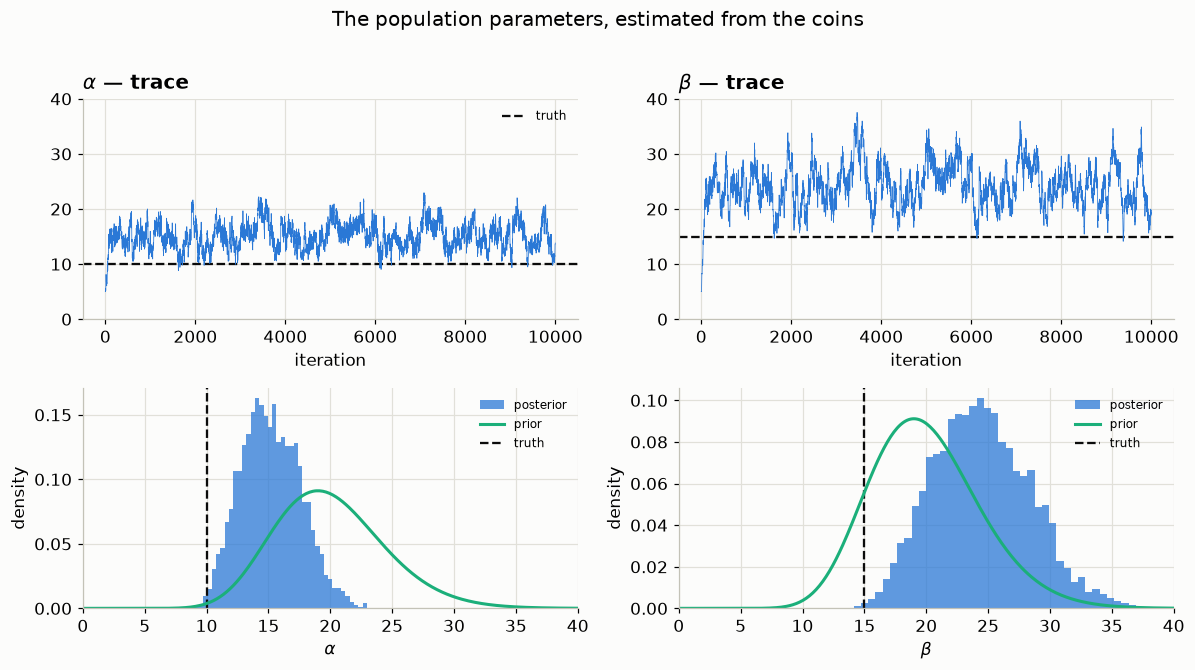

In [12]:
BURN = 2000
phi_post = phi_hier[BURN:]
p_post = p_hier[BURN:]

fig, axes = plt.subplots(2, 2, figsize=(11, 6.0))
for k, (name, truth, prior) in enumerate([(r"$\alpha$", TRUE_ALPHA, PRIOR_ALPHA),
                                          (r"$\beta$", TRUE_BETA, PRIOR_BETA)]):
    ax = axes[0, k]
    ax.plot(phi_hier[:, k], lw=0.5, color=S.PRIMARY)
    S.truth_line(ax, truth, label="truth")
    ax.set(title=f"{name} — trace", xlabel="iteration", ylim=(0, 40))
    if k == 0:
        ax.legend(fontsize=8)

    ax = axes[1, k]
    ax.hist(phi_post[:, k], bins=40, density=True, color=S.PRIMARY, alpha=0.75,
            label="posterior")
    g = np.linspace(0, 40, 300)
    ax.plot(g, stats.gamma.pdf(g, prior[0], scale=1 / prior[1]), color=S.ALT,
            lw=2, label="prior")
    S.truth_line(ax, truth, axis="x")
    ax.set(xlabel=name, ylabel="density", xlim=(0, 40))
    ax.legend(fontsize=8)
fig.suptitle("The population parameters, estimated from the coins", y=1.01)
fig.tight_layout()

print(f"alpha: true {TRUE_ALPHA:5.1f}   posterior mean {phi_post[:, 0].mean():5.1f}"
      f"   89% [{np.percentile(phi_post[:, 0], 5.5):.1f}, "
      f"{np.percentile(phi_post[:, 0], 94.5):.1f}]")
print(f"beta : true {TRUE_BETA:5.1f}   posterior mean {phi_post[:, 1].mean():5.1f}"
      f"   89% [{np.percentile(phi_post[:, 1], 5.5):.1f}, "
      f"{np.percentile(phi_post[:, 1], 94.5):.1f}]")

Look at those two panels before moving on. They do not say what a recovery
plot usually says: $\alpha$ sits well above the true 10, $\beta$ above the true
15, and neither 89% interval covers its truth.

Nothing is broken. Two things are going on.

<details class="sbi-warn" open>
<summary>⚠️ <b>Read the <i>ratio</i>, not the two parameters</b></summary>

$\alpha$ and $\beta$ are individually poorly determined and strongly
correlated — the plot immediately below shows it. What 24 coins pin down is the
**population mean** $\alpha/(\alpha+\beta)$. What they say much less about is
the *total* $\alpha + \beta$, which sets how concentrated the population is,
and which is the direction the two parameters trade off along.

So the marginals miss while the quantity the data determined is fine. This is
the marginal-versus-joint problem from Day 2 at 15:00, in a model small enough
to see whole.

</details>

coefficient of variation — population mean : 0.048
                          total (a + b)    : 0.155   (3x less well determined)


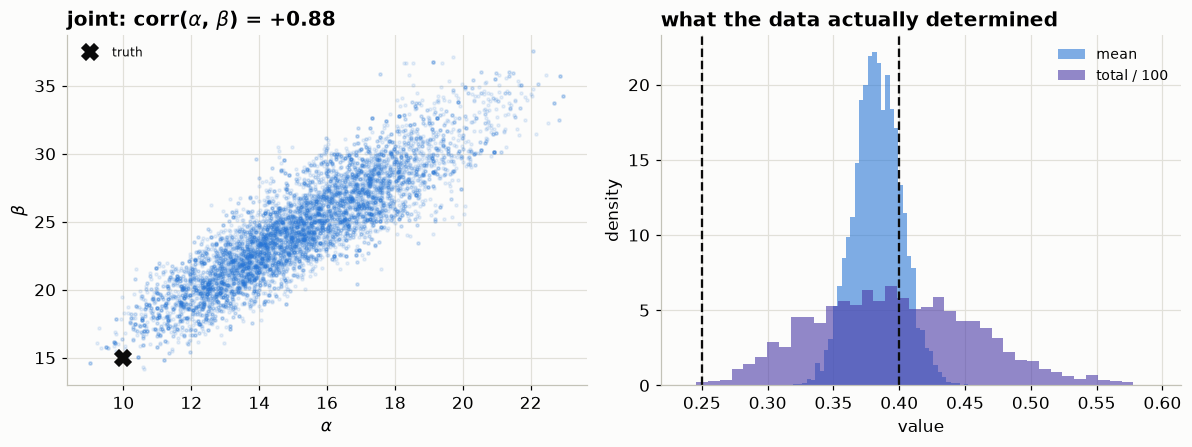

In [13]:
mean_draws = phi_post[:, 0] / (phi_post[:, 0] + phi_post[:, 1])
conc_draws = phi_post[:, 0] + phi_post[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot(phi_post[:, 0], phi_post[:, 1], "o", color=S.PRIMARY, ms=2, alpha=0.1,
         ls="none")
S.truth_point(ax1, TRUE_ALPHA, TRUE_BETA)
r = np.corrcoef(phi_post[:, 0], phi_post[:, 1])[0, 1]
ax1.set(title=rf"joint: corr($\alpha$, $\beta$) = {r:+.2f}", xlabel=r"$\alpha$",
        ylabel=r"$\beta$")
ax1.legend(fontsize=8)

for vals, truth, lbl, colour in [(mean_draws, pop_mean, "mean", S.PRIMARY),
                                 (conc_draws / 100, (TRUE_ALPHA + TRUE_BETA) / 100,
                                  r"total / 100", S.NAIVE)]:
    ax2.hist(vals, bins=40, density=True, color=colour, alpha=0.6, label=lbl)
    ax2.axvline(truth, color=S.TRUTH, ls="--", lw=1.5)
ax2.set(title="what the data actually determined", xlabel="value", ylabel="density")
ax2.legend(fontsize=9)
fig.tight_layout()

cv = lambda v: v.std() / v.mean()
print(f"coefficient of variation — population mean : {cv(mean_draws):.3f}")
print(f"                          total (a + b)    : {cv(conc_draws):.3f}"
      f"   ({cv(conc_draws) / cv(mean_draws):.0f}x less well determined)")

### And the prior is doing the rest

The other half of the explanation is the $\text{Gamma}(20, 1)$ prior. Its mean
is 20 — above both true values — so it pushes the concentration up. The R
script offers a noninformative alternative on the next line, commented out.
Run both and the question settles itself.

In [14]:
def fit_with_prior(pa, pb, label):
    with pm.Model(coords={"coin": np.arange(S_COINS)}):
        a = pm.Gamma("alpha", alpha=pa[0], beta=pa[1])
        b = pm.Gamma("beta", alpha=pb[0], beta=pb[1])
        pp = pm.Beta("p", alpha=a, beta=b, dims="coin")
        pm.Binomial("x", n=N_FLIPS, p=pp, observed=x, dims="coin")
        idt = pm.sample(draws=1500, tune=1500, chains=4, cores=4,
                        nuts_sampler="pymc", target_accept=0.9,
                        progressbar=False, random_seed=RANDOM_SEED)
    d = idt.posterior.dataset
    al, be = d["alpha"].values.ravel(), d["beta"].values.ravel()
    ci = lambda v: np.percentile(v, [5.5, 94.5])
    covers = lambda v, t: "yes" if ci(v)[0] <= t <= ci(v)[1] else "NO"
    print(f"{label}")
    for nm, v, t in [("alpha", al, TRUE_ALPHA), ("beta", be, TRUE_BETA),
                     ("pop. mean", al / (al + be), pop_mean)]:
        lo, hi = ci(v)
        print(f"   {nm:10s} {v.mean():6.2f}   89% [{lo:5.2f}, {hi:6.2f}]"
              f"   covers truth? {covers(v, t)}")
    return idt


_ = fit_with_prior((20.0, 1.0), (20.0, 1.0), "Gamma(20, 1) — 'somewhat informed'")
print()
_ = fit_with_prior((0.1, 0.1), (0.1, 0.1), "Gamma(0.1, 0.1) — noninformative")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, beta, p]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 1 seconds.


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, beta, p]


Gamma(20, 1) — 'somewhat informed'
   alpha       15.00   89% [11.54,  18.80]   covers truth? NO
   beta        24.08   89% [18.51,  30.35]   covers truth? NO
   pop. mean    0.38   89% [ 0.36,   0.41]   covers truth? yes



Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 1 seconds.


Gamma(0.1, 0.1) — noninformative
   alpha        9.36   89% [ 5.16,  14.86]   covers truth? yes
   beta        15.36   89% [ 8.41,  24.58]   covers truth? yes
   pop. mean    0.38   89% [ 0.34,   0.42]   covers truth? yes


With the vague prior, $\alpha$ and $\beta$ both recover. With the informative
one they do not — while the **population mean covers the truth either way**.

A hyperprior is not a formality you fill in to make the model run. With 24
groups there is little information about the population's *spread*, so what you
assert about it largely survives into the answer. The $p_i$ barely notice —
they depend on the mean, which the data do determine — but a sentence about
$\alpha$ itself is mostly a sentence about your prior.

### Did estimating the population cost us anything?

RMSE  no pooling                 0.0407
RMSE  population known (cheating)   0.0381
RMSE  hierarchical (estimated)      0.0377


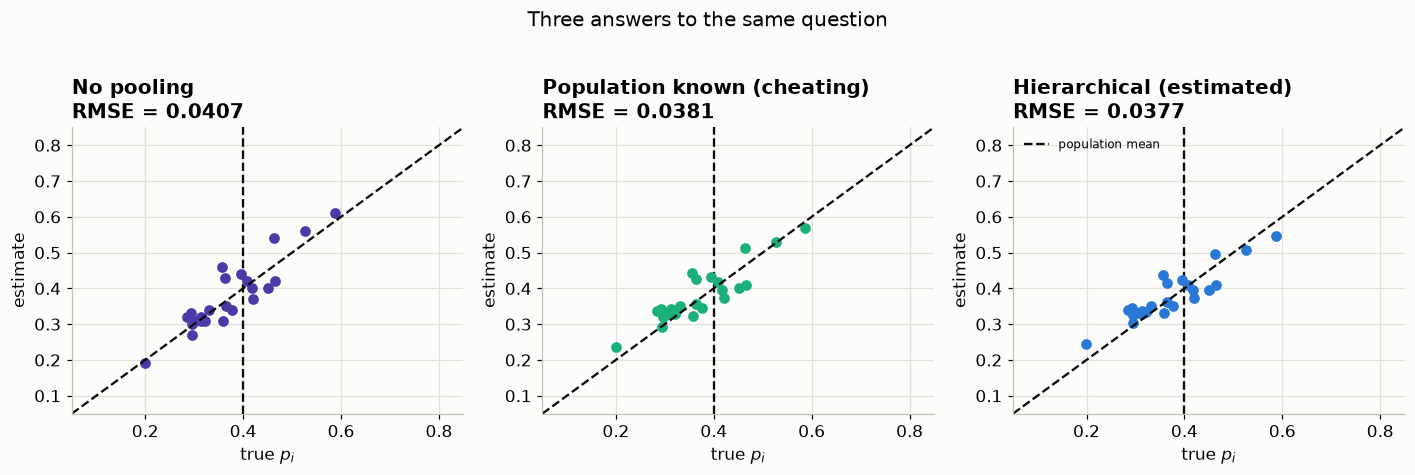

In [15]:
est_hier = p_post.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
r_naive = recovery_panel(axes[0], naive, "No pooling", S.NAIVE)
r_known = recovery_panel(axes[1], est_known, "Population known (cheating)", S.ALT)
r_hier = recovery_panel(axes[2], est_hier, "Hierarchical (estimated)", S.PRIMARY)
axes[2].legend(fontsize=8, loc="upper left")
fig.suptitle("Three answers to the same question", y=1.02)
fig.tight_layout()

print(f"RMSE  no pooling                 {r_naive:.4f}")
print(f"RMSE  population known (cheating){r_known:9.4f}")
print(f"RMSE  hierarchical (estimated)   {r_hier:9.4f}")

<details class="sbi-tip" open>
<summary>💡 <b>The result worth remembering</b></summary>

The hierarchical fit lands close to the one that was *told* the right answer,
while estimating the population from the same 24 coins it is shrinking. You do
not pay much for the honesty.

It works because the population is estimated from **all** the coins. Each one
is noisy, but $\alpha$ and $\beta$ see 24 at once, and there is far more
information about where coins sit in general than about where coin 7 sits.

</details>

### Shrinkage, drawn directly

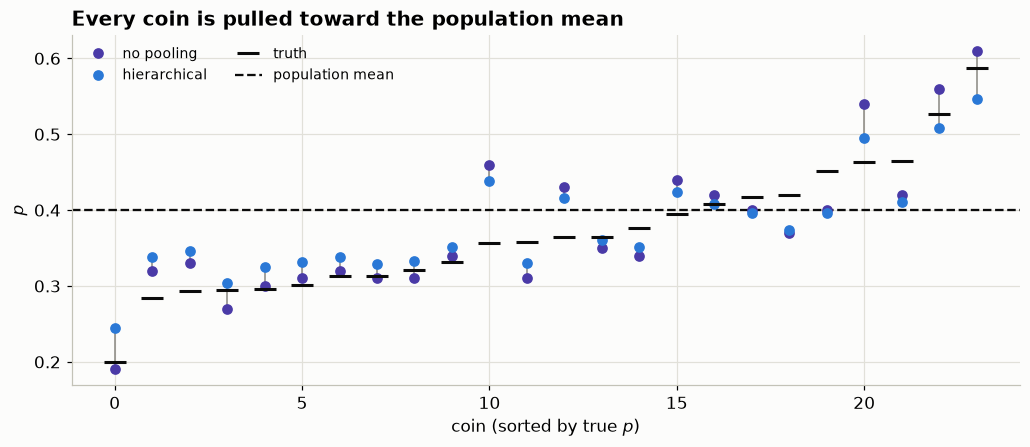

In [16]:
order = np.argsort(true_p)
fig, ax = plt.subplots(figsize=(9.5, 4.2))
for k, j in enumerate(order):
    ax.plot([k, k], [naive[j], est_hier[j]], "-", color=S.MUTED, lw=1, zorder=1)
ax.plot(range(S_COINS), naive[order], "o", color=S.NAIVE, ms=6, ls="none",
        label="no pooling")
ax.plot(range(S_COINS), est_hier[order], "o", color=S.PRIMARY, ms=6, ls="none",
        label="hierarchical")
ax.plot(range(S_COINS), true_p[order], "_", color=S.TRUTH, ms=14, mew=2,
        ls="none", label="truth")
S.truth_line(ax, pop_mean, label="population mean")
ax.set(title="Every coin is pulled toward the population mean",
       xlabel="coin (sorted by true $p$)", ylabel="$p$")
ax.legend(fontsize=9, ncol=2)
fig.tight_layout()

Every arrow points inward, and the outermost coins move furthest. That looks
like the model treating extreme coins with extra suspicion. It is not — and
the actual rule is simple enough to write down.

Hold $\alpha, \beta$ fixed for a moment. The Beta is conjugate to the
Binomial, so coin $j$'s posterior is $\text{Beta}(\alpha + x_j,\ \beta + n -
x_j)$, with mean

$$
\mathbb{E}[p_j] \;=\; \frac{\alpha + x_j}{\alpha + \beta + n}
\;=\; \underbrace{w}_{\text{own data}} \cdot \frac{x_j}{n}
\;+\; (1 - w) \cdot \underbrace{\frac{\alpha}{\alpha+\beta}}_{\text{population mean}},
\qquad w = \frac{n}{n + \alpha + \beta}.
$$

A weighted average, and the weight depends on $n$ and $\alpha + \beta$ — not
on $x_j$. So **every coin is shrunk by the same fraction**; what differs is how
far each one has to travel.

In [17]:
a_hat, b_hat = phi_post[:, 0].mean(), phi_post[:, 1].mean()
w = N_FLIPS / (N_FLIPS + a_hat + b_hat)

print(f"alpha + beta = {a_hat + b_hat:5.1f}   <- a 'prior sample size', in flips")
print(f"n            = {N_FLIPS}")
print(f"w            = {w:.3f}    weight on the coin's own flips")
print(f"1 - w        = {1 - w:.3f}    shrinkage, the SAME for all {S_COINS} coins\n")

predicted = w * naive + (1 - w) * (a_hat / (a_hat + b_hat))
print(f"largest gap between that formula and the sampler: "
      f"{np.abs(predicted - est_hier).max():.4f}")

pull = np.abs(naive - est_hier)
far = np.abs(naive - pop_mean) > np.median(np.abs(naive - pop_mean))
print(f"\nabsolute pull  far from the mean : {pull[far].mean():.4f}")
print(f"               near the mean     : {pull[~far].mean():.4f}")
# Pooled ratio, not a mean of per-coin ratios: one coin sits essentially ON the
# population mean, and dividing by its ~zero distance would blow up.
dist = np.abs(naive - pop_mean)
print(f"pull / distance, far             : {pull[far].sum() / dist[far].sum():.3f}")
print(f"                 near            : {pull[~far].sum() / dist[~far].sum():.3f}"
      f"   <- the same fraction")

alpha + beta =  39.6   <- a 'prior sample size', in flips
n            = 100
w            = 0.716    weight on the coin's own flips
1 - w        = 0.284    shrinkage, the SAME for all 24 coins

largest gap between that formula and the sampler: 0.0023

absolute pull  far from the mean : 0.0328
               near the mean     : 0.0113
pull / distance, far             : 0.268
                 near            : 0.308   <- the same fraction


The last two numbers are the point. In **absolute** terms the extreme coins
move about three times as far; as a **fraction of their distance** to the
population mean, every coin moves by the same amount. Nothing is treating
extreme coins specially — they simply start further away.

<details class="sbi-key" open>
<summary>🔑 <b>What actually controls how much a group shrinks</b></summary>

Read $\alpha + \beta$ as a **prior sample size**, measured in flips. Here it
is about 40, against $n = 100$ real flips per coin, so each coin's estimate is
roughly 70% its own data and 30% the population. Change either number and the
weight moves:

| flips per coin | $1 - w$, the shrinkage |
|---|---|
| 10 | 0.80 |
| 100 | 0.28 |
| 1000 | 0.04 |

**Data quantity is the knob.** A group with few observations is shrunk hard; a
group with many is left alone. Every coin here has exactly 100 flips, which is
why the fraction came out constant and only the distance varied — that is a
property of this tidy simulated design, not of hierarchical models.

In `hierarchical-mcmc.ipynb` the participants deliberately differ in how much
data they contribute, and you will see the same formula produce *different*
shrinkage per participant. Same rule, different thing varying.

</details>

## 6. The same model, in PyMC

Everything above was written out so that nothing is mysterious. Here is the
identical model as PyMC states it — and note that we can use the **number of
heads** rather than the individual flips, since a Binomial count is a
sufficient statistic for a sequence of Bernoulli trials.

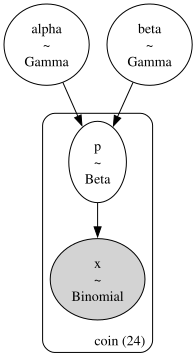

In [18]:
with pm.Model(coords={"coin": np.arange(S_COINS)}) as hier_model:
    alpha = pm.Gamma("alpha", alpha=PRIOR_ALPHA[0], beta=PRIOR_ALPHA[1])
    beta = pm.Gamma("beta", alpha=PRIOR_BETA[0], beta=PRIOR_BETA[1])
    p = pm.Beta("p", alpha=alpha, beta=beta, dims="coin")
    pm.Binomial("x", n=N_FLIPS, p=p, observed=x, dims="coin")

pm.model_to_graphviz(hier_model)

That graph is the slide's diagram, drawn by the library from the model you
wrote. The box is the plate over coins; `alpha` and `beta` sit outside it,
shared.

In [19]:
with hier_model:
    idata = pm.sample(draws=1500, tune=1500, chains=4, cores=4,
                      nuts_sampler="pymc", target_accept=0.9,
                      progressbar=False, random_seed=RANDOM_SEED)

print(az.summary(idata, var_names=["alpha", "beta"], kind="all").to_string())
print(f"\ntruth: alpha = {TRUE_ALPHA}, beta = {TRUE_BETA}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, beta, p]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 1 seconds.


        mean    sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean mcse_sd
alpha     15  2.27       12       19      8220      4900  1.00     0.025   0.018
beta   24.08  3.67       19       30      8335      5072  1.00      0.04   0.029

truth: alpha = 10.0, beta = 15.0


### Does the thirty-line sampler agree with the library?

alpha  hand-written 15.19   PyMC 15.00
beta   hand-written 24.46   PyMC 24.08
largest per-coin disagreement: 0.0021


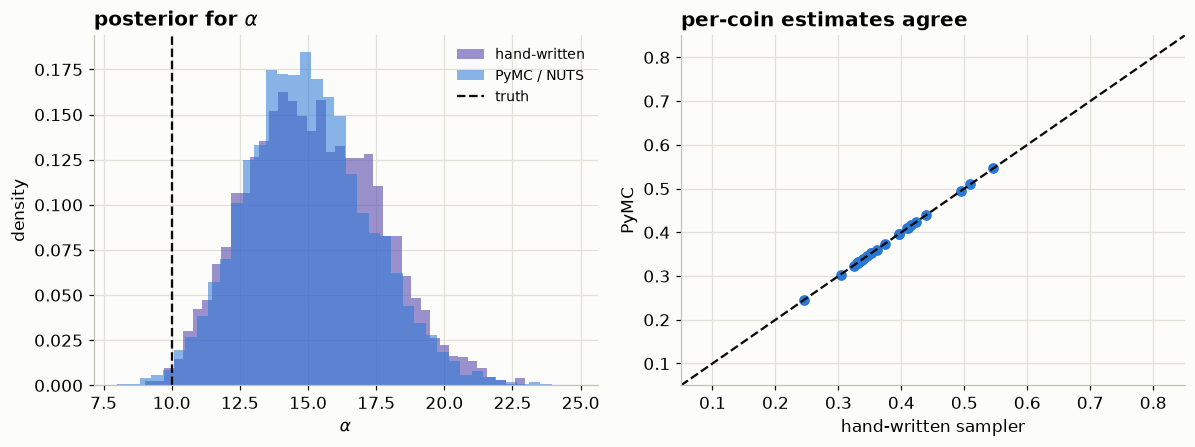

In [20]:
post = idata.posterior.dataset
pymc_alpha = post["alpha"].values.ravel()
pymc_beta = post["beta"].values.ravel()
est_pymc = post["p"].values.reshape(-1, S_COINS).mean(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
for vals, colour, lbl in [(phi_post[:, 0], S.NAIVE, "hand-written"),
                          (pymc_alpha, S.PRIMARY, "PyMC / NUTS")]:
    ax1.hist(vals, bins=40, density=True, color=colour, alpha=0.55, label=lbl)
S.truth_line(ax1, TRUE_ALPHA, axis="x")
ax1.set(title=r"posterior for $\alpha$", xlabel=r"$\alpha$", ylabel="density")
ax1.legend(fontsize=9)

ax2.plot(est_hier, est_pymc, "o", color=S.PRIMARY, ms=6, ls="none")
lims = (0.05, 0.85)
ax2.plot(lims, lims, "--", color=S.TRUTH, lw=1.5)
ax2.set(title="per-coin estimates agree", xlabel="hand-written sampler",
        ylabel="PyMC", xlim=lims, ylim=lims)
fig.tight_layout()

print(f"alpha  hand-written {phi_post[:, 0].mean():5.2f}   PyMC {pymc_alpha.mean():5.2f}")
print(f"beta   hand-written {phi_post[:, 1].mean():5.2f}   PyMC {pymc_beta.mean():5.2f}")
print(f"largest per-coin disagreement: {np.abs(est_hier - est_pymc).max():.4f}")

They agree, which is the point of writing the sampler out: PyMC is doing the
same thing, faster and with better diagnostics.

Worth quantifying "faster". Ours ran 10,000 iterations; NUTS ran 1,500 draws
per chain and returns a far larger effective sample size, because a random walk
in 26 dimensions — 24 coins plus two hyperparameters — is a poor way to
explore.

In [21]:
ess_pymc = float(az.ess(idata, var_names=["alpha"]).alpha)
dt_hand = az.convert_to_datatree({"alpha": phi_post[None, :, 0]})
ess_hand = float(az.ess(dt_hand, var_names=["alpha"]).alpha)
print(f"ESS for alpha — hand-written: {ess_hand:7.1f} out of {phi_post.shape[0]:,} draws")
print(f"                PyMC / NUTS : {ess_pymc:7.1f} out of "
      f"{post.sizes['chain'] * post.sizes['draw']:,} draws")

ESS for alpha — hand-written:    65.7 out of 8,000 draws
                PyMC / NUTS :  8220.4 out of 6,000 draws


## 7. Exercises

### Exercise 1 — how many coins do you need?

The population was estimated from 24 coins. Re-run the PyMC model with the
first 5 coins only, and compare the width of the posterior for the population
mean. How much of the hierarchy's benefit survives?

<details>
<summary>Solution</summary>

```python
k = 5
with pm.Model(coords={"coin": np.arange(k)}) as small:
    a = pm.Gamma("alpha", alpha=PRIOR_ALPHA[0], beta=PRIOR_ALPHA[1])
    b = pm.Gamma("beta", alpha=PRIOR_BETA[0], beta=PRIOR_BETA[1])
    pp = pm.Beta("p", alpha=a, beta=b, dims="coin")
    pm.Binomial("x", n=N_FLIPS, p=pp, observed=x[:k], dims="coin")
    idata_small = pm.sample(draws=1500, tune=1500, chains=4, cores=4,
                            nuts_sampler="pymc", target_accept=0.9,
                            progressbar=False, random_seed=RANDOM_SEED)
```

With five coins the population is barely identified and the posterior for
$\alpha$ leans heavily on its Gamma prior. The shrinkage still happens, but
it is being driven by your prior rather than by the data — which is fine as
long as you know it, and misleading if you do not.

</details>

### Exercise 2 — an outlier coin

Set `true_p[0] = 0.95` before generating the data, so one coin genuinely does
not belong to the population. Refit. What happens to that coin's estimate, and
to $\alpha$ and $\beta$?

<details>
<summary>What to notice</summary>

Two things, and the second is the one people miss. The outlier is pulled
sharply downward — the model does not believe it. And the *population* is
dragged toward it, so **every other coin's estimate moves too**.

That is the cost of the assumption stated plainly: in a hierarchical model
there is no such thing as a local error. A single badly-behaved participant
contaminates the group parameters, and through them everyone else. Fixes exist
— a heavier-tailed population, or an explicit mixture with an outlier
component — and all of them amount to saying out loud what you think the
population really looks like.

</details>

## What to take away

<details class="sbi-tip" open>
<summary>💡 <b>The four things that matter</b></summary>

1. **A hierarchy is a prior you estimate.** The population distribution is a
   prior on each coin, and the only new idea is that its parameters are
   unknown and inferred alongside everything else.
2. **Shrinkage is deliberate bias that lowers error.** Individual estimates
   move toward the population mean, and the extreme ones move most. Here that
   cut RMSE against no pooling at all.
3. **Estimating the population costs surprisingly little.** The hierarchical
   fit came close to the one handed the true $\alpha, \beta$ — because the
   population is informed by every coin at once.
4. **Read the joint.** $\alpha$ and $\beta$ are individually poorly
   determined and strongly correlated; the population *mean* is what the data
   pin down. Reporting a marginal interval for $\alpha$ alone would misstate
   the result — here those intervals miss the truth while the mean covers it.
5. **The hyperprior is a real assumption.** With 24 groups there is little
   information about the population's spread, so what you assert about it
   survives into the answer. Swapping Gamma(20, 1) for Gamma(0.1, 0.1) moved
   $\alpha$ from 15.0 to 9.4 against a truth of 10.

</details>

**Where this goes next.** `hierarchical-mcmc.ipynb` picks up exactly here and
asks what this model does to the *geometry* of the posterior — the funnel that
appears when a group-level scale gets small, why it biases the answer rather
than merely slowing the sampler, and what centered versus non-centered
parameterization does about it.